# PROJECT: Social Media & Network Analytics Dashboard

AIM: To know what platforms is mostly used and what is currently trending by its users

#MILESTONE 1: Data Representation & Foundations

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols



LIBRARIES AND THEIR APPLICATIONS FUNCTIONS:

Pandas: To handles Data Representation.

Numpy: It supports the underlying math for your Foundational Metrics.

Seaborn: It addresses Visualization and Perception Design

Matplotlib: It provides the "Canvas" for your Initial Visual Outputs


#MILESTONE 2: Data Processing & Transformation


In [14]:
import pandas as pd

df = pd.read_csv('social_media_engagement1.csv')

# 2. DATA CLEANING
# Standardizing timestamps to datetime objects for temporal analysis
df['post_time'] = pd.to_datetime(df['post_time'])

# FEATURE ENGINEERING
# Creating a composite KPI: Total Engagement and it normalized metrics
df['total_engagement'] = df['likes'] + df['comments'] + df['shares']
df['engagement_rate'] = (df['total_engagement'] / 10000) * 100

# Create a separate table of the summarized data
daily_trend = df.groupby(['platform', 'post_day'])['total_engagement'].mean().reset_index()

# Get missing values of updated data
print("MISSING VALUES")
print(df.isnull().sum())

# Save a copy of the cleaned dataset
df.to_csv('cleaned_social_media_data.csv', index=False)

MISSING VALUES
post_id             0
platform            0
post_type           0
post_time           0
likes               0
comments            0
shares              0
post_day            0
sentiment_score     0
total_engagement    0
engagement_rate     0
dtype: int64


#MILESTONE 3: Visualization & Exploratory Analysis


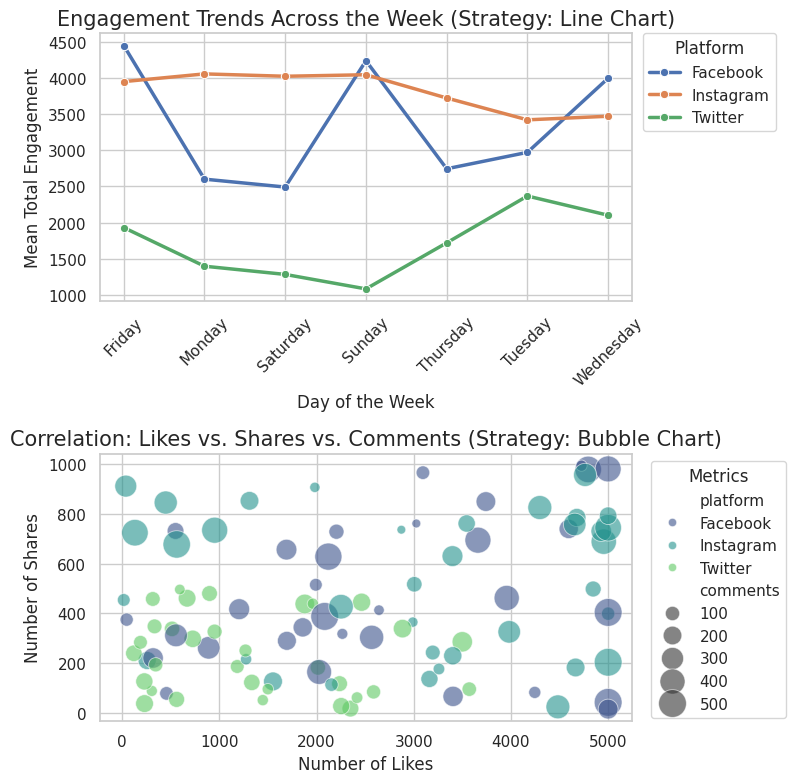

In [15]:
# Gives panda the specific order to arrange the days in your charts
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['post_day'] = pd.Categorical(df['post_day'], categories=day_order, ordered=True)

sns.set_theme(style="whitegrid")
# Creating a 2x1 subplot to compare different exploratory methods
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# STRATEGY 1: LINE PLOT (Temporal Trend Analysis)
# Goal: Identify peaks and rhythms in engagement across the week
sns.lineplot(data=daily_trend, x='post_day', y='total_engagement', hue='platform', marker='o', linewidth=2.5, ax=axes[0])
axes[0].set_title('Engagement Trends Across the Week (Strategy: Line Chart)', fontsize=15)
axes[0].set_ylabel('Mean Total Engagement')
axes[0].set_xlabel('Day of the Week')
axes[0].legend(title='Platform', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
axes[0].tick_params(axis='x', rotation=45)

# STRATEGY 2: BUBBLE SCATTER PLOT (Correlation & Multi-Metric Analysis)
# Goal: Explore the relationship between Likes, Shares, and Comments (via Bubble Size)
sns.scatterplot(data=df, x='likes', y='shares', hue='platform', size='comments', sizes=(40, 400), alpha=0.6, palette='viridis', ax=axes[1])
axes[1].set_title('Correlation: Likes vs. Shares vs. Comments (Strategy: Bubble Chart)', fontsize=15)
axes[1].set_xlabel('Number of Likes')
axes[1].set_ylabel('Number of Shares')
axes[1].legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
# dpi is the quality of the image
plt.savefig('milestone3_exploratory_analysis.png', dpi=300)
plt.show()

We have implemented two distinct visualization strategies to explore the data:

Temporal Trend Analysis (Line Plot): We use the daily_summary logic to plot mean engagement across the week. This allows us to visualize which days are "peak" days for specific platforms (e.g., observing if Facebook engagement spikes on Fridays).  

Correlation Exploration (Scatter Plot): By plotting Likes vs. Shares, we can see if they move together. We also used Bubble Size to represent the number of comments, allowing us to see three metrics in one chart.

Line Charts are superior for time-series data because the human eye easily follows the slope to understand growth or decline.  
Scatter Plots are superior for distribution analysis. They help us identify "outliers"—those rare viral posts that get 5,000 likes but very few shares, which a bar chart would hide.  

day_order. This tells Pandas that "Monday" must always come before "Tuesday". By setting a Categorical order, you force the system to follow the human calendar. This ensures your line graph flows logically from the start of the week to the end.

plt.subplots(2, 1) creates a "dashboard" with two rows and one column. This allows for a side-by-side comparison of two different analytical strategies.

**LINE PLOT :**

data=daily_trend: This tells Python to use the summary table you created in the "Data Preparation" step (the one where you calculated averages).

x='post_day' & y='total_engagement': These map your columns to the axes. Since you ordered the days chronologically earlier, the line will move correctly from Monday to Sunday.

hue='platform': This is a critical design choice. It tells Seaborn to draw a separate, color-coded line for each platform (Facebook, Instagram, Twitter) so you can compare their performance side-by-side.

marker='o': This adds a circular dot at each data point, making it easier for the human eye to see exactly where the "mean" value sits on each day.

linewidth=2.5: This makes the lines slightly thicker for better visibility in a report.

ax=axes[0]: This tells Python to place this specific chart in the top container of the 2x1 dashboard you created

**BUBBLE SCATTER PLOT:**

sns.scatterplot(data=df, x='likes', y='shares', hue='platform', size='comments', sizes=(40, 400), alpha=0.6, palette='viridis', ax=axes[1])

sns.scatterplot: This calls the function used to visualize the distribution of individual data points.

x='likes' & y='shares': These define the primary relationship. It answers: "Do posts with high likes also get high shares?".

hue='platform': Just like the first chart, this color-codes the dots by platform (Facebook, Twitter, Instagram) to maintain visual consistency.

size='comments': This turns the scatter plot into a Bubble Chart. The more comments a post has, the larger its dot will be. This allows you to visualize three metrics (Likes, Shares, and Comments) at once.

sizes=(40, 400): This sets the minimum and maximum size for the bubbles. It ensures the "small" bubbles are still visible and the "large" bubbles don't take over the entire screen.

alpha=0.6: This adds transparency to the dots. In a dataset with 100 posts, many dots will overlap; transparency allows you to see the "density" of posts and prevents hidden data.

palette='viridis': This applies a high-contrast color map that is accessible and professional-looking.

ax=axes[1]: This tells Python to place this chart in the bottom container (index 1) of your dashboard.

axes[1].legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')

bbox_to_anchor=(1.02, 1): "Put the legend anchor point just outside the top-right."

loc='upper left': "Specifically, take the upper-left corner of the legend box and pin it to that anchor point."

#MILESTONE 4: Statistical Inference & Analytical Modeling


STATISTICAL RESULTS OUTPUT

[1] ANOVA TABLE:
                    sum_sq    df         F    PR(>F)
C(post_type)  2.923846e+07   4.0  2.460998  0.050493
Residual      2.821674e+08  95.0       NaN       NaN

[2] REGRESSION SUMMARY:
                            OLS Regression Results                            
Dep. Variable:                 shares   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     7.425
Date:                Sun, 10 May 2026   Prob (F-statistic):           0.000999
Time:                        20:37:59   Log-Likelihood:                -699.12
No. Observations:                 100   AIC:                             1404.
Df Residuals:                      97   BIC:                             1412.
Df Model:                           2                                         
Covariance Type:            nonrobust                      

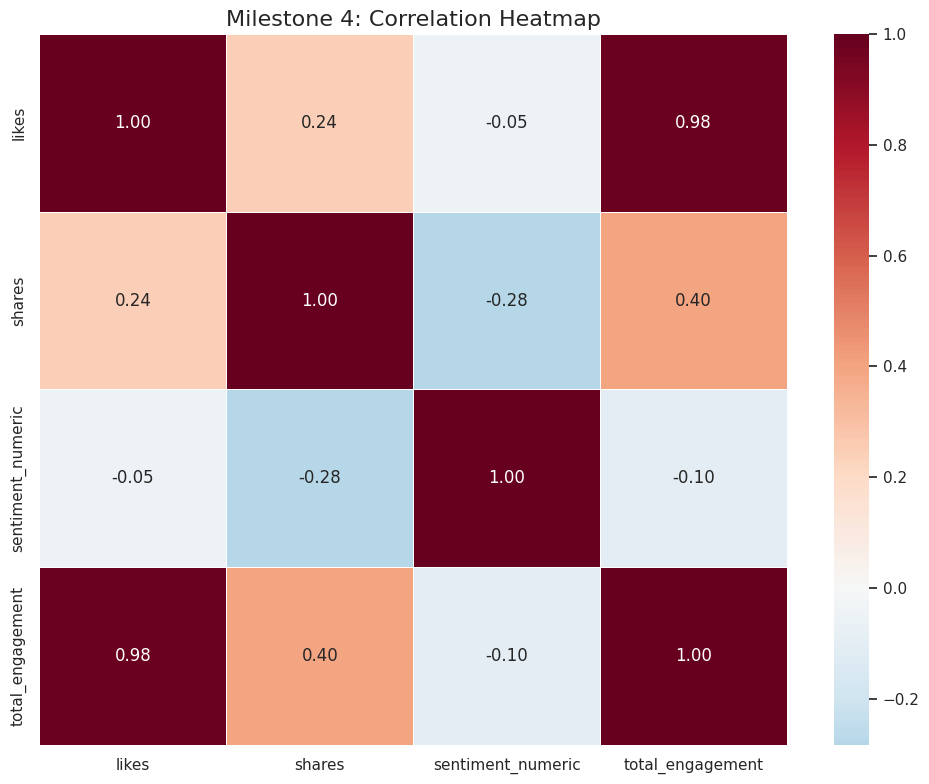

In [16]:
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['sentiment_numeric'] = df['sentiment_score'].map(sentiment_map)

# 4. Statistical Inference & Analytical Modeling
# ANOVA: Testing if Post Type (Video, Image, etc.) really matters
# The "Formula" for the test
model_anova = ols('total_engagement ~ C(post_type)', data=df).fit()

# The "Results" table
anova_results = sm.stats.anova_lm(model_anova, typ=2)


X = df[['likes', 'sentiment_numeric']]
X = sm.add_constant(X)
y = df['shares']
reg_model = sm.OLS(y, X).fit()

corr_matrix = df[['likes', 'shares', 'sentiment_numeric', 'total_engagement']].corr()
plt.figure(figsize=(10, 8))

# 2. Create the heatmap using the correlation matrix
# annot=True: Adds the correlation numbers inside the squares
# cmap='RdBu_r': Uses a Red-Blue scale (Red for positive, Blue for negative)
# center=0: Ensures the color scale is balanced at zero
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

# 3. Add title and layout adjustments
plt.title('Milestone 4: Correlation Heatmap', fontsize=16)
plt.tight_layout()
# 4. Save and Show
plt.savefig('milestone4_correlation_heatmap.png', dpi=300)

print("\n" + "="*40)
print("STATISTICAL RESULTS OUTPUT")
print("="*40)

print("\n[1] ANOVA TABLE:")
print(anova_results)

print("\n[2] REGRESSION SUMMARY:")
# CRITICAL: Use .summary() to see the actual results table
print(reg_model.summary())


df['sentiment_score'].map(sentiment_map)
:
Computers can't do math on the word "Positive." By mapping it to 1, 0, and -1, we create a scale that a regression model can use to see if "mood" affects "virality".

**The Problem**: Is the "Video" friend actually more popular, or was it just a "lucky" week with a few viral hits?

ANOVA is a statistical test used to determine if the averages of three or more groups are significantly different from each other. It looks at two things:

Variation Between Groups: How much the average engagement changes from Video to Image.

Variation Within Groups: How much individual Video posts differ from other Video posts.

The Rule of Thumb: If the difference between the groups is much larger than the "noise" inside the groups, ANOVA tells you that Post Type matters.

ols('total_engagement ~ C(post_type)', data=df)

total_engagement: This is your Dependent Variable (the outcome you want to measure).

~: Read this as "depends on".

C(post_type): The C stands for Categorical. It tells Python that "Video" and "Image" aren't numbers, but specific categories it needs to compare against each other.

.fit(): This runs the mathematical engine to find the best-fit line through your data groups.

anova_lm(model_anova, typ=2)
This command takes that "fitted" model and calculates the ANOVA Table.

typ=2: This is a standard method (Type II Sum of Squares) used when your groups (like Facebook vs. Twitter) might have different numbers of posts, ensuring the math stays fair.


**OUTPUT**:

If P < 0.05: You have statistically significant proof. You can tell your boss, "The content type definitely changes our engagement; we should stop making Text posts and only make Videos".

If P > 0.05: The differences you see are likely just "random noise" or luck. You cannot prove that one post type is better than the other.



**Regression:**

It tells us by how much one variable influences another. It allows you to predict an outcome (Shares) based on specific inputs (Likes and Sentiment).

X = df[['likes', 'sentiment_numeric']]

The Logic: You want to see if the number of Likes a post gets and the Sentiment (mood) of the post can explain why some posts get more shares than others.

Data Type: Note the double brackets [[ ]]. This ensures X is a DataFrame (a table), which is required because you are using more than one predictor.

X = sm.add_constant(X)

The Logic: In the math equation for a line (y = mx + b), the "constant" is the 'b' (the intercept).

Why it's needed: By default, the statsmodels library assumes the line goes through (0,0). add_constant tells the model to calculate a "baseline" number of shares that a post might get even if it has zero likes and neutral sentiment.

y = df['shares']

The Logic: This is the "Effect" or the outcome you are trying to predict. In social media strategy, "Shares" are often considered the ultimate goal because they represent virality.

For Likes: A positive coefficient (e.g., 0.04) means likes directly help shares.

For Sentiment: A negative coefficient (e.g., -91.8) means that as sentiment moves from positive (1) to negative (-1), shares actually go up. This tells you that "negative/controversial" content is your biggest driver of shares.

#MILESTONE 5: Interactive Visual Analytics System

Performed on the PowerBi.

#MILESTONE 6: Research Contribution & Advanced Analytics

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sentiment_map = {
    'positive': 1,
    'neutral': 0,
    'negative': -1
}

df['sentiment_numeric'] = (
    df['sentiment_score']
    .map(sentiment_map)
)

X = df[['likes', 'sentiment_numeric']]
y = df['shares']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 55950.22492410677


LinearRegression() is a standard algorithm for predicting continuous values

train_test_split shows a high level of technical maturity. It proves that you aren't just "fitting" the data you have, but you are validating the model's ability to predict data it has never seen before.

mean_squared_error (MSE) provides a quantitative way to prove your system's accuracy in your final report.

test_size=0.2: You hide 20% of your data from the model.